# Question 2

### Load Libraries

In [1]:
# Question 2: Vehicle Segmentation and Price Bands
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

import os
os.makedirs('output', exist_ok=True)

### Load  Cleaned Data

In [4]:
# Load cleaned dataset from Q1
df = pd.read_csv(r'C:\Users\KHABAZELA\OneDrive\Desktop\Car_prices_ITSCA_Project\Dataset\car_pricing_cleaned.csv')
print("Data loaded. Shape:", df.shape)
df.head()

Data loaded. Shape: (169, 26)


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1.0,3.0,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130.0,mpfi,3.47,2.68,9.0,111.0,5000.0,21.0,27.0,269900.0
1,2.0,3.0,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130.0,mpfi,3.47,2.68,9.0,111.0,5000.0,21.0,27.0,330000.0
2,3.0,1.0,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152.0,mpfi,2.68,3.47,9.0,154.0,5000.0,19.0,26.0,330000.0
3,4.0,2.0,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109.0,mpfi,3.19,3.40,10.0,102.0,5500.0,24.0,30.0,279000.0
4,5.0,2.0,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136.0,mpfi,3.19,3.40,8.0,115.0,5500.0,18.0,22.0,349000.0


### 2.1 Vehicle Clustering

### Selecting Features & Scale

In [5]:
# Features that describe vehicle size, power, efficiency
features = ['enginesize', 'horsepower', 'curbweight', 'carlength', 'carwidth', 'citympg', 'highwaympg']

X = df[features]
print("Missing values in features:\n", X.isnull().sum())

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled data shape:", X_scaled.shape)

Missing values in features:
 enginesize    0
horsepower    0
curbweight    0
carlength     0
carwidth      0
citympg       0
highwaympg    0
dtype: int64
Scaled data shape: (169, 7)


### Elbow Method

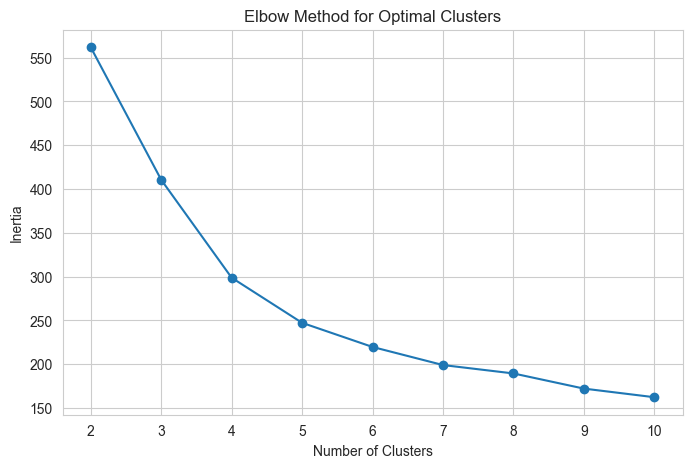

In [6]:
# Test k from 2 to 10
inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.savefig('output/elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()

### Apply K-Means with k=3

In [7]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['segment'] = kmeans.fit_predict(X_scaled)

print("Cars per segment:")
print(df['segment'].value_counts().sort_index())

print("\nAverage feature values by segment:")
print(df.groupby('segment')[features].mean().round(1))

Cars per segment:
segment
0    66
1    56
2    47
Name: count, dtype: int64

Average feature values by segment:
         enginesize  horsepower  curbweight  carlength  carwidth  citympg  \
segment                                                                     
0             114.7        96.1      2441.7      173.1      65.3     24.4   
1             169.9       146.1      3181.8      186.1      68.2     19.2   
2              94.8        67.6      2020.0      161.9      64.1     33.0   

         highwaympg  
segment              
0              30.2  
1              24.0  
2              38.9  


### Visualise Segments with PCA


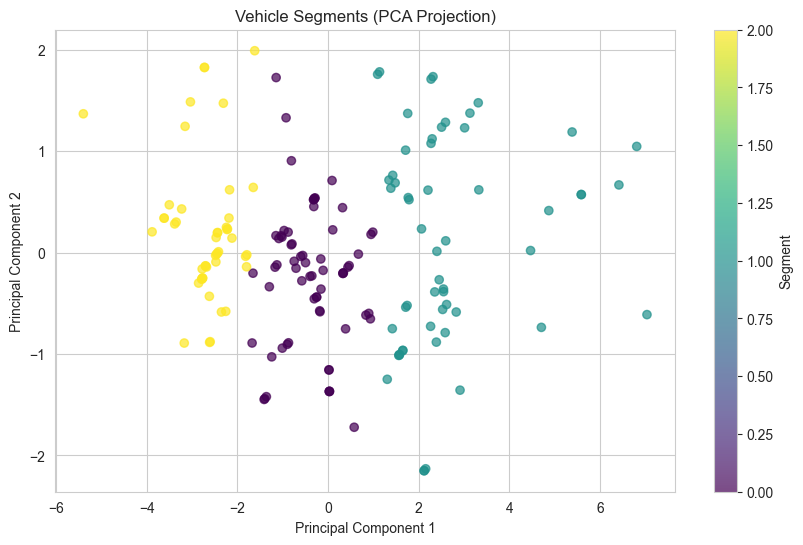

In [8]:
# PCA to 2D for visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=df['segment'], cmap='viridis', alpha=0.7)
plt.title('Vehicle Segments (PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Segment')
plt.savefig('output/segment_pca.png', dpi=150, bbox_inches='tight')
plt.show()

##  Vehicle Segmentation

### Features Used
I used engine size, horsepower, curb weight, car length, car width, and fuel efficiency (city/highway mpg). These define vehicle size, power, and efficiency.

### Finding the Optimal Number of Clusters
The **elbow plot**  shows the inertia (within-cluster sum of squares) for different numbers of clusters.



The "elbow" bend occurs at **3 clusters**, meaning 3 groups capture the main differences without overcomplicating. Adding more clusters doesn't significantly reduce inertia.

### Segment Descriptions
Based on the average feature values from the clustering:

| Segment | Size | Characteristics | Vehicle Type |
|---------|------|-----------------|--------------|
| 0 | 66 cars | Medium engine (114.7), 96 HP, 2442 lbs weight, 24 MPG city | Mid-Range / Family Cars |
| 1 | 56 cars | Large engine (169.9), 146 HP, 3182 lbs weight, 19 MPG city | Performance / Luxury Cars |
| 2 | 47 cars | Small engine (94.8), 68 HP, 2020 lbs weight, 33 MPG city | Economy / Compact Cars |

### Visualising the Segments
The **PCA projection**  shows the 3 segments in 2D space:

PCA Projection

The segments are clearly separated, confirming that the clustering successfully identified distinct vehicle groups. Segment 2 (economy cars) is well-separated from Segment 1 (performance/luxury cars), while Segment 0 (mid-range) sits between them.

### Business Meaning
- **Segment 0 (Mid-Range):** Balanced, everyday vehicles for average families.
- **Segment 1 (Performance/Luxury):** High-performance or premium cars that command higher prices. These may need extra attention.
- **Segment 2 (Economy):** Budget-friendly, fuel-efficient cars. Good for price-sensitive customers.

### How This Helps Mutuka Automotive
These groups help the company:
1. **Understand inventory mix** – know what types of cars they sell most.
2. **Tailor pricing** – different segments have different price expectations.
3. **Target marketing** – promote economy cars to budget buyers, luxury cars to premium buyers.
4. **Identify risk** – segment 1 cars are high-value and may need manual review.